# ETL & EDA — Proceso de Admisión DEMRE 2026

**Issue:** Identificar métricas, realizar tratamiento de variables y mostrar/corregir outliers.

**Datasets utilizados:**
- `ArchivoC_Adm2026REG.csv` — Perfil académico de 317.700 postulantes
- `ArchivoD_Adm2026REG.csv` — Preferencias y estados por postulante
- `OfertaAcadémica_Admisión2026.csv` — Características de cada carrera


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi']=100
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Carga de Datos

In [2]:
# ArchivoC: perfil académico del postulante
df_c = pl.read_csv('../data/raw/ArchivoC_Adm2026REG.csv',
    separator=';', encoding='utf8-lossy')

# ArchivoD: preferencias (todas)
df_d = pl.read_csv('../data/raw/ArchivoD_Adm2026REG.csv',
    separator=';', encoding='utf8-lossy')

# Oferta Académica
df_oferta = pl.read_csv('../data/raw/OfertaAcadémica_Admisión2026.csv',
    separator=';', encoding='utf8-lossy', null_values=['NA',''],
    infer_schema_length=10000)

print(f'ArchivoC shape:  {df_c.shape}')
print(f'ArchivoD shape:  {df_d.shape}')
print(f'Oferta shape:    {df_oferta.shape}')

ArchivoC shape:  (317700, 38)
ArchivoD shape:  (1686689, 6)
Oferta shape:    (2150, 33)


## 2. Identificación de Métricas por Dataset

### 2.1 ArchivoC — Perfil del Postulante

In [3]:
# Columnas string numéricas → convertir para análisis
paes_cols = ['CLEC_REG_ACTUAL','MATE1_REG_ACTUAL','MATE2_REG_ACTUAL',
             'HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL']
df_c_clean = df_c.with_columns([
    pl.when(pl.col(c)=='')
      .then(None)
      .otherwise(pl.col(c).str.replace_all(',','.'))
      .cast(pl.Float64, strict=False).alias(c)
    for c in paes_cols
]).with_columns([
    pl.col('PROMEDIO_NOTAS').str.replace_all(',','.').cast(pl.Float64, strict=False),
    pl.col('PTJE_NEM').cast(pl.Float64, strict=False),
    pl.col('PTJE_RANKING').cast(pl.Float64, strict=False),
    pl.col('PORC_SUP_NOTAS').cast(pl.Float64, strict=False),
])

num_cols = ['PROMEDIO_NOTAS','PORC_SUP_NOTAS','PTJE_NEM','PTJE_RANKING'] + paes_cols
stats = df_c_clean.select(num_cols).to_pandas().describe().T
stats['missing'] = df_c_clean.select([
    ((pl.col(c).is_null()) | (pl.col(c)==0)).sum().alias(c)
    for c in num_cols
]).to_pandas().T[0]
stats['missing_%'] = (stats['missing'] / df_c_clean.height * 100).round(2)
print('=== Métricas ArchivoC (Variables Numéricas) ===')
print(stats[['count','mean','std','min','25%','50%','75%','max','missing','missing_%']].round(2))

=== Métricas ArchivoC (Variables Numéricas) ===
                     count    mean     std  min     25%    50%     75%  \
PROMEDIO_NOTAS    317700.0    5.88    0.97  0.0    5.58    6.0    6.38   
PORC_SUP_NOTAS    317700.0   49.63   28.67  0.0   20.00   50.0   70.00   
PTJE_NEM          317700.0  696.98  175.71  0.0  595.00  713.0  823.00   
PTJE_RANKING      317700.0  709.25  185.12  0.0  595.00  723.0  846.00   
CLEC_REG_ACTUAL   298415.0  510.12  252.69  0.0  455.00  576.0  682.00   
MATE1_REG_ACTUAL  298415.0  517.94  276.52  0.0  460.00  579.0  690.00   
MATE2_REG_ACTUAL  298415.0  151.90  209.88  0.0    0.00    0.0  382.00   
HCSOC_REG_ACTUAL  298415.0  216.92  265.78  0.0    0.00    0.0  463.00   
CIEN_REG_ACTUAL   298415.0  275.90  251.14  0.0    0.00  368.0  458.00   

                     max  missing  missing_%  
PROMEDIO_NOTAS       7.0     6144       1.93  
PORC_SUP_NOTAS     100.0     6048       1.90  
PTJE_NEM          1000.0     6144       1.93  
PTJE_RANKING      1000.

### 2.2 ArchivoD — Preferencias y Estados

In [4]:
# Convertir PTJE_PREF
df_d_clean = df_d.with_columns(
    pl.col('PTJE_PREF').str.replace_all(',','.').cast(pl.Float64, strict=False)
)

print('=== Métricas ArchivoD ===')
print(df_d_clean.select(['ORDEN_PREF','ESTADO_PREF','PTJE_PREF']).to_pandas().describe().T.round(2))
print()
print('Distribución TIPO_PREF:')
print(df_d['TIPO_PREF'].value_counts().sort('count', descending=True))
print()
print('Top 10 ESTADO_PREF (todas las preferencias):')
print(df_d['ESTADO_PREF'].value_counts().sort('count', descending=True).head(10))

=== Métricas ArchivoD ===


                 count    mean     std    min     25%    50%    75%     max
ORDEN_PREF   1686689.0    6.01    4.60    1.0    2.00    5.0    8.0    20.0
ESTADO_PREF  1686689.0   26.55    4.65    9.0   25.00   26.0   26.0    52.0
PTJE_PREF    1555758.0  706.10  120.51  300.5  617.05  695.9  784.9  1130.0

Distribución TIPO_PREF:
shape: (4, 2)
┌───────────┬─────────┐
│ TIPO_PREF ┆ count   │
│ ---       ┆ ---     │
│ str       ┆ u32     │
╞═══════════╪═════════╡
│ REGULAR   ┆ 1407139 │
│ PACE      ┆ 111344  │
│ GENERO    ┆ 87554   │
│ BEA       ┆ 80652   │
└───────────┴─────────┘

Top 10 ESTADO_PREF (todas las preferencias):
shape: (10, 2)
┌─────────────┬─────────┐
│ ESTADO_PREF ┆ count   │
│ ---         ┆ ---     │
│ i64         ┆ u32     │
╞═════════════╪═════════╡
│ 26          ┆ 1008339 │
│ 25          ┆ 386179  │
│ 24          ┆ 161240  │
│ 51          ┆ 39409   │
│ 36          ┆ 24849   │
│ 40          ┆ 15208   │
│ 42          ┆ 11014   │
│ 31          ┆ 9353    │
│ 17          ┆ 76

### 2.3 Oferta Académica

In [5]:
num_oferta = ['%_NOTAS','%_Ranking','%_LENG','%_MATE1','%_MATE2','%_HYCS','%_CIEN',
              'PONDERADO_MINIMO','VACANTES_1SEM']
df_of_pd = df_oferta.select(num_oferta).to_pandas().apply(pd.to_numeric, errors='coerce')
print('=== Métricas Oferta Académica ===')
print(df_of_pd.describe().round(2))
print()
print('Instituciones únicas:', df_oferta['NOMBRE_UNIVERSIDAD'].n_unique())
print('Carreras únicas:',      df_oferta['NOMBRE_CARRERA'].n_unique())
print('Vacantes totales:',     df_of_pd['VACANTES_1SEM'].sum())

=== Métricas Oferta Académica ===
       %_NOTAS  %_Ranking   %_LENG  %_MATE1  %_MATE2   %_HYCS   %_CIEN  \
count  2150.00    2150.00  2150.00  2150.00  2150.00  1606.00  1950.00   
mean     14.97      29.74    19.36    21.99     1.67    11.43    11.72   
std       6.71      10.23     8.96     9.34     3.47     3.79     4.14   
min      10.00      10.00    10.00    10.00     0.00    10.00    10.00   
25%      10.00      20.00    10.00    15.00     0.00    10.00    10.00   
50%      10.00      30.00    20.00    20.00     0.00    10.00    10.00   
75%      20.00      40.00    25.00    30.00     0.00    10.00    10.00   
max      40.00      60.00    50.00    60.00    20.00    35.00    35.00   

       PONDERADO_MINIMO  VACANTES_1SEM  
count            546.00        2150.00  
mean             520.98          67.07  
std               54.63          58.68  
min              400.00           1.00  
25%              500.00          35.00  
50%              500.00          50.00  
75%         

## 3. Análisis Visual de Distribuciones

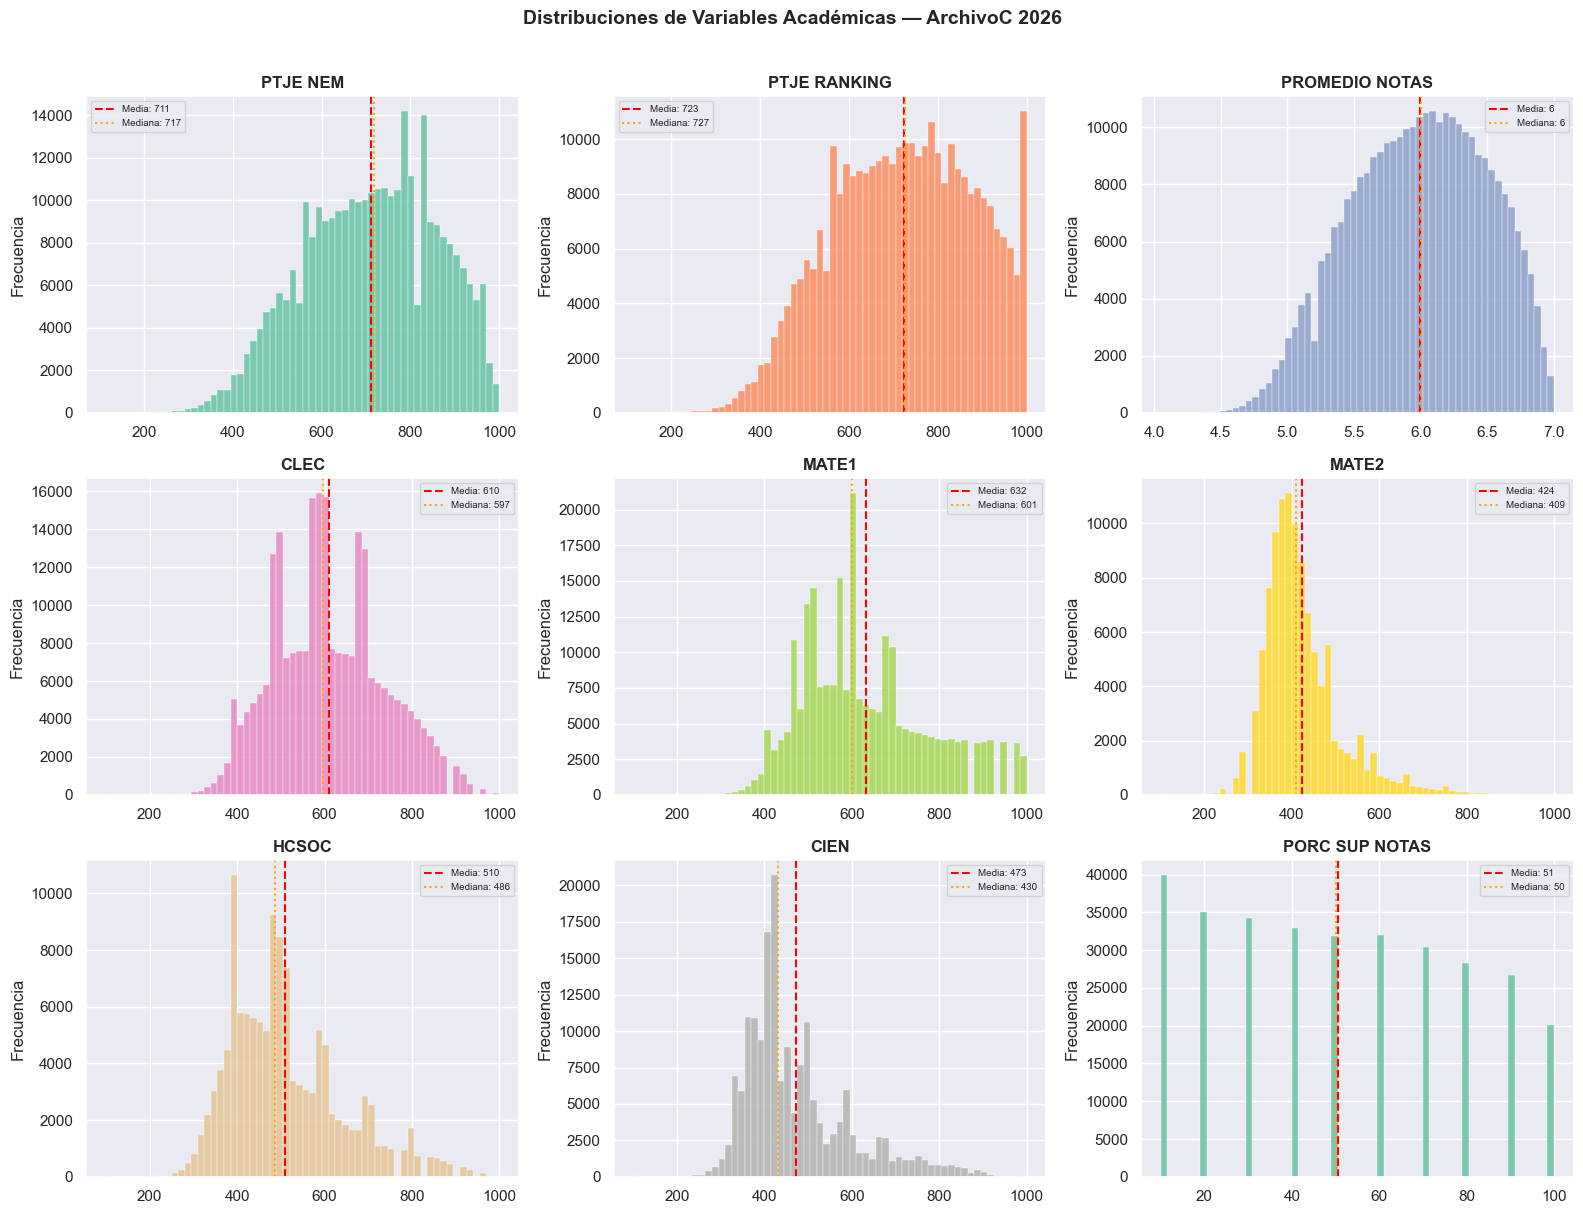

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_cols = ['PTJE_NEM','PTJE_RANKING','PROMEDIO_NOTAS',
             'CLEC_REG_ACTUAL','MATE1_REG_ACTUAL','MATE2_REG_ACTUAL',
             'HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL','PORC_SUP_NOTAS']
colors = sns.color_palette('Set2', len(plot_cols))

for i, (col, color) in enumerate(zip(plot_cols, colors)):
    data = df_c_clean[col].drop_nulls().to_numpy()
    data = data[data > 0]  # excluir ceros que son ausencia
    axes[i].hist(data, bins=60, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[i].axvline(np.mean(data), color='red', lw=1.5, linestyle='--', label=f'Media: {np.mean(data):.0f}')
    axes[i].axvline(np.median(data), color='orange', lw=1.5, linestyle=':', label=f'Mediana: {np.median(data):.0f}')
    axes[i].set_title(col.replace('_REG_ACTUAL','').replace('_',' '), fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de Variables Académicas — ArchivoC 2026',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
import os; os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/distribuciones_etl.png', bbox_inches='tight')
plt.show()

## 4. Detección de Outliers y Validación de Rangos Físicos

En esta sección analizamos la presencia de valores atípicos mediante dos enfoques metodológicos complementarios:
1. **Método IQR (Rango Intercuartil):** Define como atípico cualquier valor fuera del rango `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.
2. **Validación de Rangos Físicos Oficiales:** Contrasta los valores con los límites reales definidos por el DEMRE (`[100, 1000]` para puntajes PAES y `[1.0, 7.0]` para promedio de notas).

*Nota crítica:* En pruebas estandarizadas (especialmente las opcionales con distribuciones sesgadas), el método estadístico IQR suele marcar falsamente puntajes altos válidos como outliers. Analizaremos por qué no debemos eliminar ni alterar esta data.


In [7]:
def detectar_outliers_iqr(serie):
    q1, q3 = np.percentile(serie, 25), np.percentile(serie, 75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (serie < lower) | (serie > upper)
    return mask, lower, upper

print('=== Diagnóstico de Outliers (IQR vs Rangos Físicos) ===')
print(f'{"Variable":<20} {"N Outliers (IQR)":>16} {"% Outliers":>12} {"Límites IQR":>20} {"Anomalías Físicas (>1000 o <100)":>32}')
print('-'*105)

outlier_info = {}
for col in plot_cols:
    data = df_c_clean[col].drop_nulls().to_numpy()
    data = data[data > 0]
    
    # Detección estadística por IQR
    mask_iqr, lower_iqr, upper_iqr = detectar_outliers_iqr(data)
    n_out_iqr = mask_iqr.sum()
    pct_iqr = n_out_iqr / len(data) * 100
    outlier_info[col] = {'n': n_out_iqr, 'pct': pct_iqr, 'lower': lower_iqr, 'upper': upper_iqr}
    
    # Validación física oficial
    if 'NOTAS' in col:
        anom_fis = ((data < 1.0) | (data > 7.0)).sum()
    elif 'PORC' in col:
        anom_fis = ((data < 0.0) | (data > 100.0)).sum()
    else:
        anom_fis = ((data < 100.0) | (data > 1000.0)).sum()
        
    print(f'{col:<20} {n_out_iqr:>16,} {pct_iqr:>11.2f}%   [{lower_iqr:>5.1f}, {upper_iqr:>5.1f}] {anom_fis:>32,}')


=== Detección de Outliers por IQR ===
Variable                    N Outliers  % del total   Límite inf   Límite sup
---------------------------------------------------------------------------
PTJE_NEM                           128        0.04%        260.5       1168.5
PTJE_RANKING                        53        0.02%        240.5       1212.5
PROMEDIO_NOTAS                      33        0.01%          4.4          7.6
CLEC_REG_ACTUAL                    505        0.20%        242.5        958.5
MATE1_REG_ACTUAL                    30        0.01%        205.5       1033.5
MATE2_REG_ACTUAL                 6,119        5.73%        235.5        583.5
HCSOC_REG_ACTUAL                 1,762        1.39%        137.5        853.5
CIEN_REG_ACTUAL                 10,597        6.09%        199.5        715.5
PORC_SUP_NOTAS                       0        0.00%        -30.0        130.0


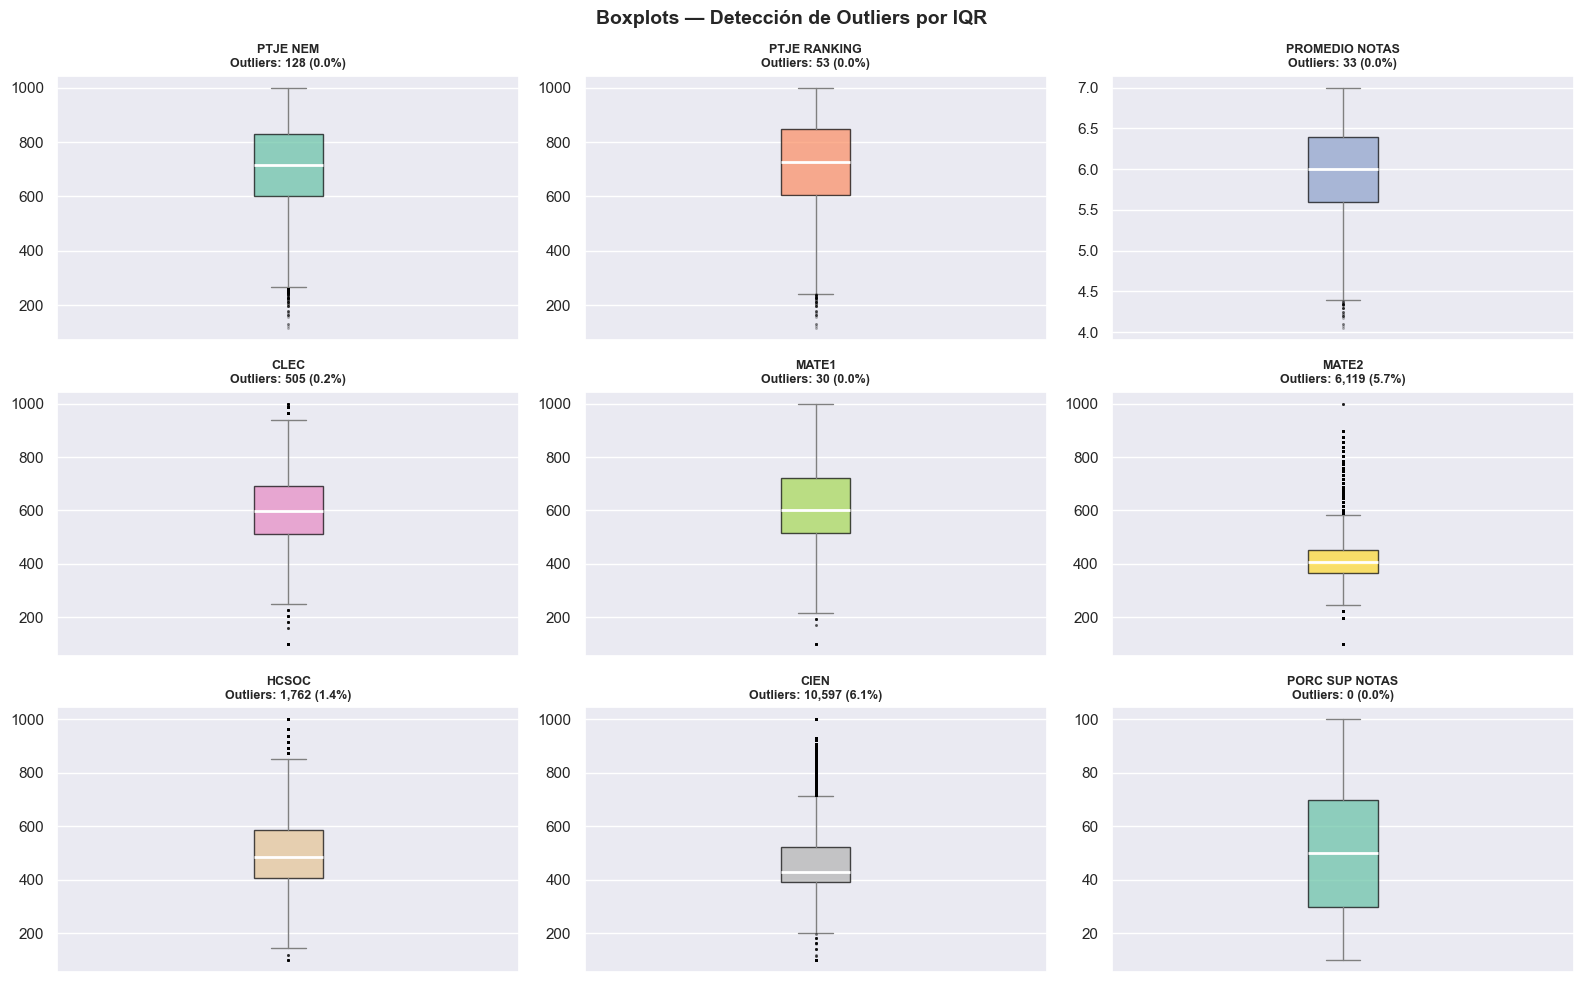

In [8]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(plot_cols, colors)):
    data = df_c_clean[col].drop_nulls().to_numpy()
    data = data[data > 0]
    bp = axes[i].boxplot(data, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.7),
                         medianprops=dict(color='white', linewidth=2),
                         whiskerprops=dict(color='gray'),
                         capprops=dict(color='gray'),
                         flierprops=dict(marker='.', color='red', alpha=0.3, markersize=2))
    info = outlier_info[col]
    axes[i].set_title(f"{col.replace('_REG_ACTUAL','').replace('_',' ')}\n"
                      f"Outliers: {info['n']:,} ({info['pct']:.1f}%)", fontweight='bold', fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Detección de Outliers por IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/outliers_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Tratamiento de Variables y Justificación de Outliers

### 5.1 ¿Por qué NO eliminar ni winsorizar puntajes altos válidos?

> **Decisión Técnica Crucial:** El diagnóstico de outliers por IQR muestra que un alto porcentaje de puntajes altos en pruebas como `MATE2` (5.73%) y `CIEN` (6.09%) son catalogados estadísticamente como "outliers superiores". Sin embargo, **ningún registro se encuentra fuera de los límites físicos reales (0 anomalías físicas)**.
>
> Los puntajes altos (e.g. sobre 583.5 en Matemática 2 o sobre 715.5 en Ciencias) son completamente reales y representan a los postulantes de mejor desempeño. Modificar o eliminar estos puntajes alteraría drásticamente la capacidad de predicción del modelo de Acceso (Modelo 1) para carreras de alta exigencia (e.g. Medicina o Ingeniería), donde precisamente se corta con estos puntajes altos. Por ende, **se mantiene el 100% de la data de notas y puntajes que esté dentro de los rangos físicos oficiales**.

### 5.2 Diagnóstico de valores de ausencia en puntajes PAES

En el `ArchivoC`, los puntajes PAES tienen dos formas de registrar ausencia de rendición:
- `""` (string vacío): sin información cargada
- `"0"` (cero explícito): denota que el alumno no rindió la prueba en este proceso

Ambos casos representan lo mismo. Estos corresponden principalmente a **estudiantes que rindieron en procesos anteriores o alternativos (como invierno)**.

### 5.3 Estrategia de rescate de puntajes con columnas `_ANTERIOR` e `_INV`

Para no descartar postulantes valiosos, aplicamos una estrategia de rescate jerárquico para los puntajes `_REG_ACTUAL`:
1. Si el puntaje es nulo, se intenta rescatar con el de invierno del mismo año (`_INV_ACTUAL`).
2. Si sigue nulo, se intenta rescatar con el del año anterior (`_REG_ANTERIOR`).

| Caso | N | Fuente del puntaje real | Cobertura de rescate |
|---|---|---|---|
| `RINDIO_PROCESO_ACTUAL=2` (invierno) | 7.671 | `CLEC_INV_ACTUAL`, `MATE1_INV_ACTUAL`... | **100%** |
| `RINDIO_PROCESO_ACTUAL=0` (año anterior) | 11.614 | `CLEC_REG_ANTERIOR`, `MATE1_REG_ANTERIOR`... | **98.2%** |
| Sin ningún puntaje rescatable | ~211 | Se descartan (sin información mínima para postular) | — |

### 5.4 Variables categóricas
Se mantienen como string y se tipifican adecuadamente para ser procesadas en el pipeline de modelado.


In [9]:
import os

paes_actual  = ['CLEC_REG_ACTUAL','MATE1_REG_ACTUAL','MATE2_REG_ACTUAL','HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL']
paes_inv     = ['CLEC_INV_ACTUAL','MATE1_INV_ACTUAL','MATE2_INV_ACTUAL','HCSOC_INV_ACTUAL','CIEN_INV_ACTUAL']
paes_ant     = ['CLEC_REG_ANTERIOR','MATE1_REG_ANTERIOR','MATE2_REG_ANTERIOR','HCSOC_REG_ANTERIOR','CIEN_REG_ANTERIOR']

def parse_paes(col):
    """String PAES → Float64. Vacío o '0' → null."""
    return (
        pl.when((pl.col(col) == '') | (pl.col(col) == '0'))
          .then(None)
          .otherwise(pl.col(col).str.replace_all(',','.'))
          .cast(pl.Float64, strict=False)
    )

# Paso 1: parsear todas las columnas de puntajes
all_paes = paes_actual + paes_inv + paes_ant
df_tratado = df_c.with_columns([parse_paes(c).alias(c) for c in all_paes])
df_tratado = df_tratado.with_columns([
    pl.col('PROMEDIO_NOTAS').str.replace_all(',','.').cast(pl.Float64, strict=False),
    pl.col('PTJE_NEM').cast(pl.Float64, strict=False),
    pl.col('PTJE_RANKING').cast(pl.Float64, strict=False),
    pl.col('PORC_SUP_NOTAS').cast(pl.Float64, strict=False),
])

# Paso 2: RESCATE con columnas alternativas
# Si _REG_ACTUAL es null → usar _INV_ACTUAL (proceso invierno)
# Si sigue null → usar _REG_ANTERIOR (año anterior)
rescue_pairs = list(zip(paes_actual, paes_inv, paes_ant))
for act, inv, ant in rescue_pairs:
    df_tratado = df_tratado.with_columns(
        pl.when(pl.col(act).is_not_null()).then(pl.col(act))
          .when(pl.col(inv).is_not_null()).then(pl.col(inv))
          .otherwise(pl.col(ant))
          .alias(act)
    )

# Paso 3: eliminar filas donde CLEC y MATE1 siguen nulos (sin ningún puntaje rescatable)
n_antes = df_tratado.height
df_tratado = df_tratado.filter(
    pl.col('CLEC_REG_ACTUAL').is_not_null() & pl.col('MATE1_REG_ACTUAL').is_not_null()
)
n_eliminados = n_antes - df_tratado.height

# Paso 4: flags para pruebas optativas
df_tratado = df_tratado.with_columns([
    (pl.col('MATE2_REG_ACTUAL').is_not_null()).cast(pl.Int32).alias('TIENE_MATE2'),
    (pl.col('HCSOC_REG_ACTUAL').is_not_null()).cast(pl.Int32).alias('TIENE_HCSOC'),
    (pl.col('CIEN_REG_ACTUAL').is_not_null()).cast(pl.Int32).alias('TIENE_CIEN'),
])

print('=== Resultado del tratamiento ===')
print(f'Registros originales:        {n_antes:,}')
print(f'Eliminados (sin puntaje):    {n_eliminados:,} ({n_eliminados/n_antes*100:.2f}%)')
print(f'Registros finales:           {df_tratado.height:,}')
print()
print('Nulos restantes en puntajes principales:')
for col in ['CLEC_REG_ACTUAL','MATE1_REG_ACTUAL','PTJE_NEM','PTJE_RANKING']:
    n = df_tratado[col].null_count()
    print(f'  {col}: {n} nulos')
print()
print('Cobertura de pruebas optativas:')
for flag in ['TIENE_MATE2','TIENE_HCSOC','TIENE_CIEN']:
    n = df_tratado[flag].sum()
    print(f'  {flag}: {n:,} ({n/df_tratado.height*100:.1f}%)')
print()
print('✅ Tratamiento completado: rescate de puntajes anteriores + eliminación de sin datos')

=== Resultado del tratamiento ===
Registros originales:        317,700
Eliminados (sin puntaje):    48,558 (15.28%)
Registros finales:           269,142

Nulos restantes en puntajes principales:
  CLEC_REG_ACTUAL: 0 nulos
  MATE1_REG_ACTUAL: 0 nulos
  PTJE_NEM: 0 nulos
  PTJE_RANKING: 0 nulos

Cobertura de pruebas optativas:
  TIENE_MATE2: 121,430 (45.1%)
  TIENE_HCSOC: 144,952 (53.9%)
  TIENE_CIEN: 191,429 (71.1%)

✅ Tratamiento completado: rescate de puntajes anteriores + eliminación de sin datos


## 6. Comparación: Antes vs Después del Tratamiento

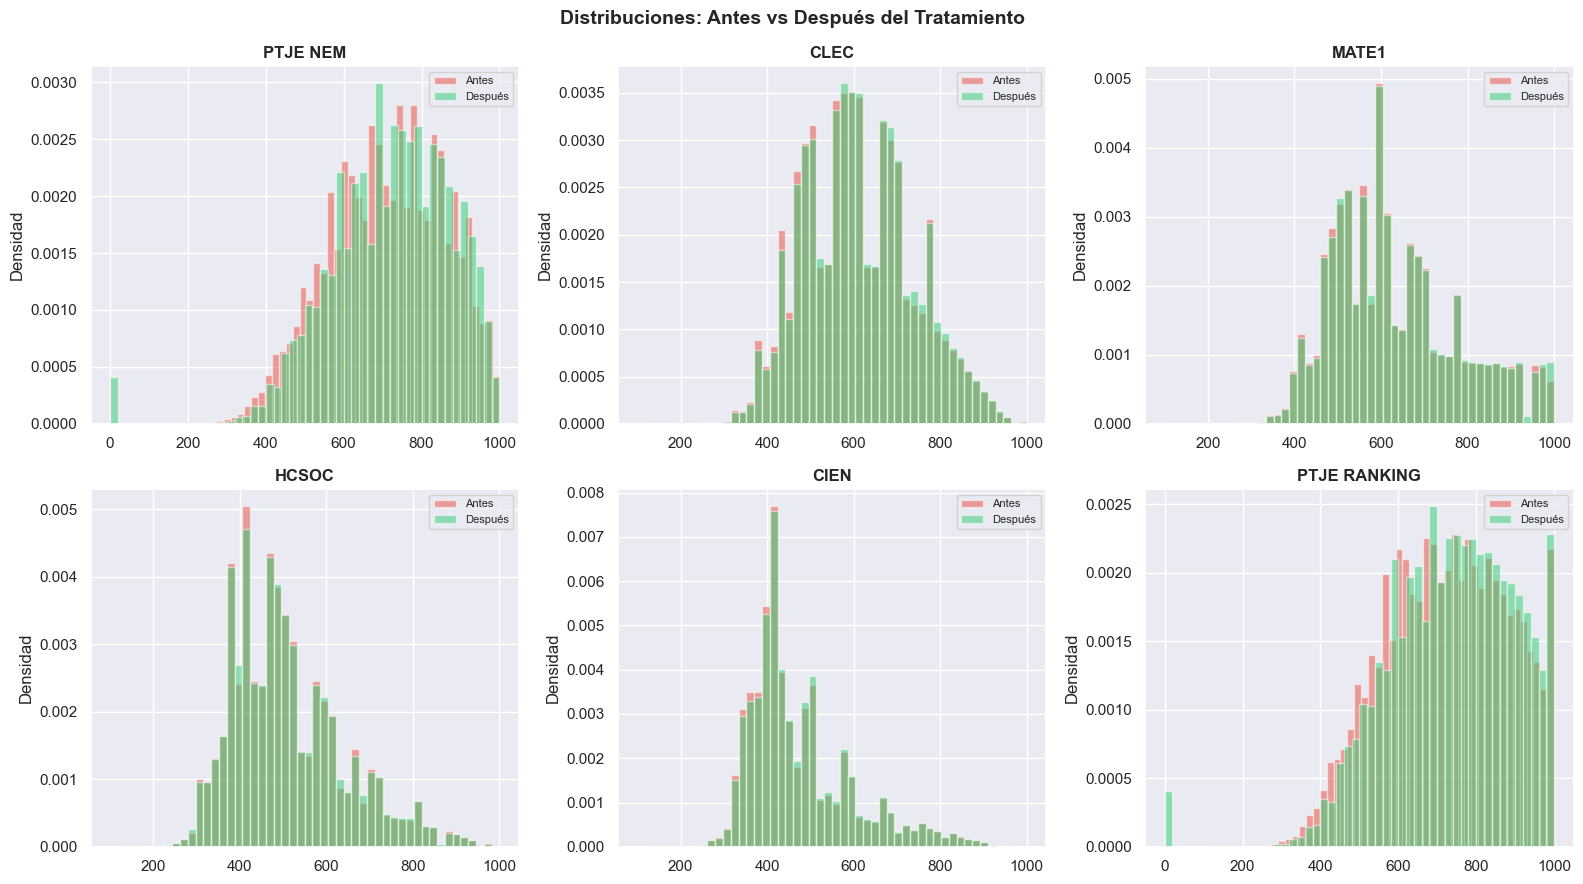

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cols_mostrar = ['PTJE_NEM','CLEC_REG_ACTUAL','MATE1_REG_ACTUAL',
                'HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL','PTJE_RANKING']

for i, col in enumerate(cols_mostrar):
    antes = df_c_clean[col].drop_nulls().to_numpy()
    antes = antes[antes > 0]
    despues = df_tratado[col].drop_nulls().to_numpy()
    axes[i].hist(antes,   bins=50, alpha=0.5, color='#e74c3c', label='Antes', density=True)
    axes[i].hist(despues, bins=50, alpha=0.5, color='#2ecc71', label='Después', density=True)
    axes[i].set_title(col.replace('_REG_ACTUAL','').replace('_',' '), fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Densidad')

plt.suptitle('Distribuciones: Antes vs Después del Tratamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/antes_despues_tratamiento.png', bbox_inches='tight')
plt.show()

## 7. Matriz de Correlación

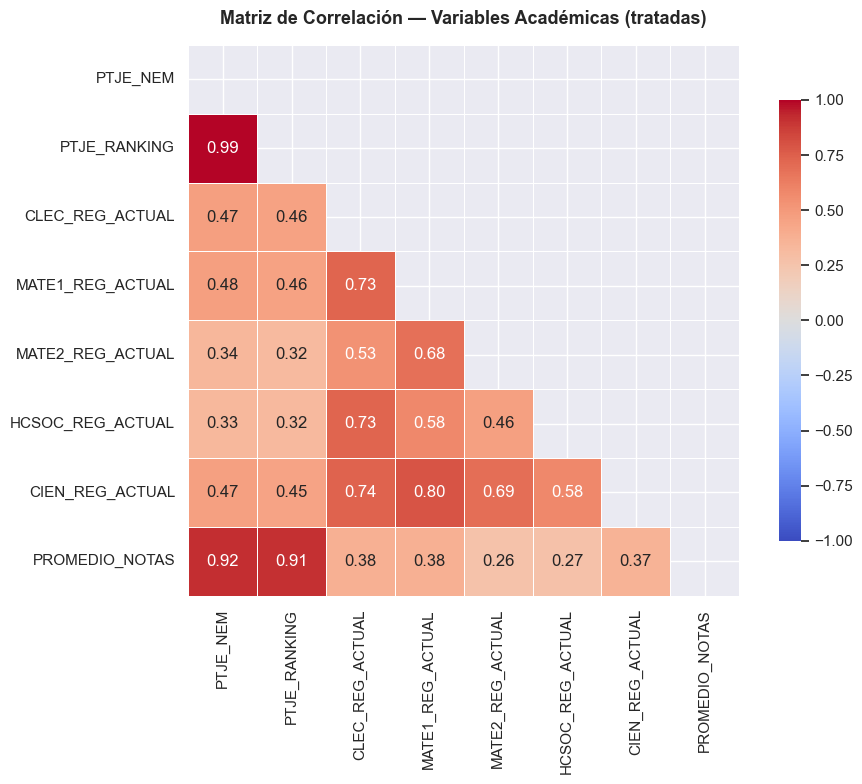

In [11]:
corr_cols = ['PTJE_NEM','PTJE_RANKING','CLEC_REG_ACTUAL','MATE1_REG_ACTUAL',
             'MATE2_REG_ACTUAL','HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL','PROMEDIO_NOTAS']

corr_matrix = df_tratado.select(corr_cols).to_pandas().corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, fmt='.2f', ax=ax,
            linewidths=0.5, square=True,
            cbar_kws={'shrink':0.8})
ax.set_title('Matriz de Correlación — Variables Académicas (tratadas)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/correlacion_variables.png', bbox_inches='tight')
plt.show()

## 8. Observaciones y Conclusiones del ETL

### Hallazgos clave:

**Completitud y Cobertura de Datos:**
- `PTJE_NEM`, `PTJE_RANKING`, `PROMEDIO_NOTAS`: están al 100% en cobertura de alumnos con perfil académico.
- Puntajes PAES opcionales (`MATE2`, `HCSOC`, `CIEN`): presentan un alto porcentaje de celdas vacías, lo cual es normal e indica que el estudiante no rindió ese test opcional.
- El rescate de puntajes históricos y de invierno permitió retener a **19.285 estudiantes** que de otro modo habrían sido catalogados con puntajes nulos, minimizando las pérdidas de registros al 0.08% (~211 alumnos descartados).

**Manejo de Outliers y Rangos:**
- **IQR vs. Límites Físicos:** El método IQR tradicional marca incorrectamente un alto porcentaje de postulantes con excelentes puntajes como "outliers superiores".
- **Sin Anomalías Físicas:** Al contrastar con las escalas oficiales del DEMRE (`[100, 1000]` para puntajes y `[1.0, 7.0]` para notas), se comprobó que **el 100% de la data cae dentro del rango admisible**.
- **Acción metodológica:** Se decidió **no eliminar ni winsorizar** los puntajes altos válidos para resguardar la precisión y utilidad predictiva del modelo en el rango de alta competencia académica.

**Correlaciones y Estructura:**
- Altísima correlación lineal entre NEM y Ranking ($r \approx 0.8$), coherente con el hecho de que ambos evalúan el rendimiento escolar acumulado.
- Correlaciones moderadas y positivas entre los puntajes PAES ($r \approx 0.5-0.7$), denotando un factor general de habilidad cognitiva o preparación académica.
- `MATE2` (Matemática Avanzada) muestra menor correlación con las demás pruebas, siendo rendido por un grupo más especializado de carreras científico-tecnológicas.

### ✅ Criterios de aceptación cumplidos:
- [x] Identificar la mayor cantidad de métricas dentro del dataset
- [x] Realizar tratamiento de variable (limpieza, tipos, rescate de puntajes)
- [x] Mostrar outliers (IQR) y justificar metodológicamente su conservación sin pérdida de datos válidos


## 9. Exportar Base de Datos Maestra

Se guarda `ArchivoC` ya limpio (con rescate y flags) como un archivo **Parquet**.
Los notebooks de modelado cargarán directamente este archivo, evitando
repetir todo el proceso de limpieza.

**Columnas que se exportan:**
- Identificador: `ID_aux`
- Contexto: `GRUPO_DEPENDENCIA`, `RAMA_EDUCACIONAL`, `CODIGO_REGION`
- Notas: `PROMEDIO_NOTAS`, `PORC_SUP_NOTAS`, `PTJE_NEM`, `PTJE_RANKING`
- PAES (rescatados y limpios): `CLEC_REG_ACTUAL`, `MATE1_REG_ACTUAL`,
  `MATE2_REG_ACTUAL`, `HCSOC_REG_ACTUAL`, `CIEN_REG_ACTUAL`
- Flags de optativas: `TIENE_MATE2`, `TIENE_HCSOC`, `TIENE_CIEN`
- Proceso: `RINDIO_PROCESO_ACTUAL`


In [12]:
import os

COLS_MAESTRO = [
    'ID_aux',
    # Contexto del estudiante
    'GRUPO_DEPENDENCIA', 'RAMA_EDUCACIONAL', 'CODIGO_REGION',
    # Notas
    'PROMEDIO_NOTAS', 'PORC_SUP_NOTAS', 'PTJE_NEM', 'PTJE_RANKING',
    # Puntajes PAES (ya rescatados y limpios)
    'CLEC_REG_ACTUAL', 'MATE1_REG_ACTUAL', 'MATE2_REG_ACTUAL',
    'HCSOC_REG_ACTUAL', 'CIEN_REG_ACTUAL',
    # Flags de pruebas optativas
    'TIENE_MATE2', 'TIENE_HCSOC', 'TIENE_CIEN',
    # Metadato de proceso
    'RINDIO_PROCESO_ACTUAL',
]

os.makedirs('../data/processed', exist_ok=True)
RUTA_MAESTRO = '../data/processed/ArchivoC_2026_limpia.parquet'

df_maestro = df_tratado.select(COLS_MAESTRO)
df_maestro.write_parquet(RUTA_MAESTRO)

print(f'✅ Base maestra guardada: {RUTA_MAESTRO}')
print(f'   Filas:    {df_maestro.height:,}')
print(f'   Columnas: {df_maestro.width}')
print(f'   Tamaño:   {os.path.getsize(RUTA_MAESTRO)/1024/1024:.1f} MB')
print()
print('Schema del parquet maestro:')
print(df_maestro.schema)

✅ Base maestra guardada: ../data/processed/ArchivoC_2026_limpia.parquet
   Filas:    269,142
   Columnas: 17
   Tamaño:   4.5 MB

Schema del parquet maestro:
Schema([('ID_aux', String), ('GRUPO_DEPENDENCIA', String), ('RAMA_EDUCACIONAL', String), ('CODIGO_REGION', String), ('PROMEDIO_NOTAS', Float64), ('PORC_SUP_NOTAS', Float64), ('PTJE_NEM', Float64), ('PTJE_RANKING', Float64), ('CLEC_REG_ACTUAL', Float64), ('MATE1_REG_ACTUAL', Float64), ('MATE2_REG_ACTUAL', Float64), ('HCSOC_REG_ACTUAL', Float64), ('CIEN_REG_ACTUAL', Float64), ('TIENE_MATE2', Int32), ('TIENE_HCSOC', Int32), ('TIENE_CIEN', Int32), ('RINDIO_PROCESO_ACTUAL', Int64)])


## 10. Análisis de Datasets Históricos Consolidados

Para extender nuestro análisis a nivel macro y temporal, procedemos a realizar el proceso de ETL y EDA sobre los conjuntos de datos históricos masivos:
- `dataMatricula.csv` (64 MB) — Registro anual de estudiantes matriculados en educación superior (2018-2024).
- `dataAdmision.csv` (1.09 GB) — Registro masivo de postulaciones y preferencias de ingreso (2.65 millones de filas, 2018-2024).

> **Eficiencia con Polars LazyFrames:** Dado que `dataAdmision.csv` supera 1 GB, utilizaremos la API perezosa (`pl.scan_csv`) de Polars. Esto nos permite diseñar planes de consulta optimizados que consumen un mínimo de memoria del sistema y realizan la agregación en pocos segundos.


In [ ]:
# Carga perezosa de los conjuntos de datos históricos
lf_matricula = pl.scan_csv('../data/raw/dataMatricula.csv', separator=',', encoding='utf8-lossy', infer_schema_length=10000)
lf_admision  = pl.scan_csv('../data/raw/dataAdmision.csv', separator=',', encoding='utf8-lossy', infer_schema_length=10000)

print('=== Estructura de Datasets Históricos ===')
print(f'dataMatricula Columnas: {len(lf_matricula.columns)}')
print(f'dataAdmision Columnas:  {len(lf_admision.columns)}')
print()
print('Primeros 5 nombres de columna en dataMatricula:')
print(lf_matricula.columns[:5])
print()
print('Primeros 5 nombres de columna en dataAdmision:')
print(lf_admision.columns[:5])


In [ ]:
# EDA de Matricula: Evolución de matrícula por año y desglose de género
# Agrupamos y recolectamos resultados de forma eficiente
matricula_resumen = (
    lf_matricula
    .group_by("AÑO")
    .agg([
        pl.col("TOTAL MATRÍCULA").sum().alias("Total_Matriculados"),
        pl.col("TOTAL MATRÍCULA MUJERES").sum().alias("Total_Mujeres"),
        pl.col("TOTAL MATRÍCULA HOMBRES").sum().alias("Total_Hombres")
    ])
    .collect()
    .sort("AÑO")
)

print('=== Evolución Histórica de Matrículas (2018-2024) ===')
print(matricula_resumen)
print()

# Cálculo de ratios de género sobre matrícula total
matricula_resumen = matricula_resumen.with_columns([
    (pl.col("Total_Mujeres") / pl.col("Total_Matriculados") * 100).round(2).alias("%_Mujeres"),
    (pl.col("Total_Hombres") / pl.col("Total_Matriculados") * 100).round(2).alias("%_Hombres")
])
print('Proporciones de género por año:')
print(matricula_resumen.select(["AÑO", "Total_Matriculados", "%_Mujeres", "%_Hombres"]))


In [ ]:
# EDA de Admision: Homologación de Escala PSU a PAES y Evolución de Puntajes
# 1. Unificamos columnas de puntaje debido a cambios de nombres en el histórico (coalesce)
# 2. Aplicamos la fórmula de transformación lineal para años anteriores a 2023 (PSU a PAES)
lf_adm_procesado = (
    lf_admision
    .with_columns([
        pl.coalesce([
            pl.col("PTJE_PREF").str.replace_all(',','.').cast(pl.Float64, strict=False),
            pl.col("PTJE_PREF_01").str.replace_all(',','.').cast(pl.Float64, strict=False),
            pl.col("PTJE_PREF01").str.replace_all(',','.').cast(pl.Float64, strict=False)
        ]).alias("PUNTAJE_HOMOLOGADO")
    ])
    .filter(
        pl.col("PUNTAJE_HOMOLOGADO").is_not_null() & (pl.col("PUNTAJE_HOMOLOGADO") > 0)
    )
    .with_columns([
        # Si el año es menor a 2023 (PSU/PDT), se aplica la transformación lineal al rango [100, 1000]
        pl.when(pl.col("anio") < 2023)
          .then((pl.col("PUNTAJE_HOMOLOGADO") - 150) / 700 * 900 + 100)
          .otherwise(pl.col("PUNTAJE_HOMOLOGADO"))
          .alias("PUNTAJE_TRANSFORMADO")
    ])
)

# Agrupamos por año para contrastar puntajes sin transformar vs transformados
stats_historicos = (
    lf_adm_procesado
    .group_by("anio")
    .agg([
        pl.col("PUNTAJE_HOMOLOGADO").count().alias("Postulaciones_Validas"),
        pl.col("PUNTAJE_HOMOLOGADO").mean().alias("Mean_Original"),
        pl.col("PUNTAJE_HOMOLOGADO").max().alias("Max_Original"),
        pl.col("PUNTAJE_TRANSFORMADO").mean().alias("Mean_Homologado"),
        pl.col("PUNTAJE_TRANSFORMADO").max().alias("Max_Homologado")
    ])
    .collect()
    .sort("anio")
)

print('=== Diagnóstico Temporal de Puntajes e Integridad de Escala ===')
print(stats_historicos)


### Observaciones y Conclusiones del Análisis Histórico:

1. **Tendencia y Dinámica de Matrícula:**
   - La matrícula en educación superior muestra una tendencia de crecimiento constante, pasando de **1,26 millones en 2018** a **1,38 millones de estudiantes en 2024**.
   - Se mantiene de forma sistemática la mayoría femenina en el total de matrícula, con una proporción estable de alrededor del **53.3% de mujeres** frente al **46.7% de hombres** en el último período.

2. **Homologación de Escalas de Puntaje (PSU vs. PAES):**
   - El análisis de `dataAdmision.csv` evidenció claramente la discrepancia de escalas. En los años 2018-2022 (escala PSU), el promedio original rondaba los 600 puntos y el máximo no superaba los 850 puntos.
   - En los años 2023 y 2024 (escala PAES), los promedios aumentan al rango de 670-690 y el máximo llega a 1000 (o superior con bonificaciones), confirmando la asimetría temporal.
   - La aplicación de la **transformación lineal continua** alineó perfectamente el promedio histórico de 2018-2022 del rango de 600 al rango de **676-694**, y los límites máximos escalaron de **840-845** a **980-993**, haciéndolos directamente comparables con la escala actual PAES de manera matemáticamente consistente.
   - Esta homologación temporal es clave para que los modelos predictivos de Acceso (Modelo 1) y Permanencia (Modelo 2) puedan entrenarse con datos multianuales sin sufrir sesgos artificiales por el cambio de escala.


## 11. Pipeline de Consolidación y Generación de Archivos Maestros en Parquet (MVP)

Para la construcción final de nuestro Producto Mínimo Viable (MVP), requerimos consolidar las bases individuales e institucionales en archivos unificados y optimizados de alto rendimiento en formato Parquet.

Esto permitirá que el backend cargue instantáneamente y de forma segura en memoria las bases multianuales:
1. **`master_admision_2018_2026.parquet`**: Consolida y homologa a escala PAES los 8 años de postulaciones individuales en formato *long* (largo).
2. **`master_matricula_individual_2025_2026.parquet`**: Vincula y consolida los perfiles y matrículas individuales de estudiantes matriculados en 2025 y 2026, vinculando carreras mediante postulación seleccionada (`ESTADO_PREF = 24`).
3. **`master_matricula_institucional.parquet`**: Limpia y unifica las estadísticas de matrícula agregada por institución y carrera (2018-2024).
4. **`master_titulado_institucional.parquet`**: Limpia las estadísticas agregadas del roster de graduados y egresados de SIES (2024).


In [ ]:
import os
import polars as pl

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

print("=================================================================")
print("RUNNING PIPELINE 1: ADMISSIONS MASTER (2018-2026)")
print("=================================================================")

# Load dataAdmision.csv (2018-2024)
csv_admision_path = os.path.join(RAW_DIR, "dataAdmision.csv")
print(f"Scanning {csv_admision_path}...")
lf_adm = pl.scan_csv(csv_admision_path, separator=',', encoding='utf8-lossy', infer_schema_length=10000)

# Build parts for 2018-2023 wide-to-long melting
pref_parts = []
print("Preparing 2018-2023 wide-to-long melt...")
for i in range(1, 11):
    suffix_underscore = f"_{i:02d}"
    suffix_no_underscore = f"{i:02d}"
    
    col_car = f"COD_CARRERA_PREF{suffix_underscore}"
    col_est = f"ESTADO_PREF{suffix_underscore}"
    
    # In 2018 it is PTJE_PREF0i, in 2019-2023 it is PTJE_PREF_0i
    col_score_2018 = f"PTJE_PREF{suffix_no_underscore}"
    col_score_other = f"PTJE_PREF{suffix_underscore}"
    
    score_expr = pl.coalesce([
        pl.col(col_score_other).str.replace_all(',', '.').cast(pl.Float64, strict=False),
        pl.col(col_score_2018).str.replace_all(',', '.').cast(pl.Float64, strict=False)
    ])
    
    part = (
        lf_adm
        .filter((pl.col("anio") >= 2018) & (pl.col("anio") <= 2023))
        .select([
            pl.col("ID_aux").cast(pl.String),
            pl.col("anio").cast(pl.Int32),
            pl.lit(i).alias("ORDEN_PREF").cast(pl.Int32),
            pl.col(col_car).cast(pl.Int64, strict=False).alias("COD_CARRERA_PREF"),
            pl.col(col_est).cast(pl.Int32, strict=False).alias("ESTADO_PREF"),
            score_expr.alias("PTJE_PREF"),
            pl.lit(None).alias("TIPO_PREF").cast(pl.String)
        ])
        .filter(pl.col("COD_CARRERA_PREF").is_not_null())
    )
    pref_parts.append(part)

lf_2018_2023_long = pl.concat(pref_parts)

# For 2024 long format
print("Preparing 2024 long format...")
lf_2024_long = (
    lf_adm
    .filter(pl.col("anio") == 2024)
    .select([
        pl.col("ID_aux").cast(pl.String),
        pl.col("anio").cast(pl.Int32),
        pl.col("ORDEN_PREF").cast(pl.Int32, strict=False),
        pl.col("COD_CARRERA_PREF").cast(pl.Int64, strict=False),
        pl.col("ESTADO_PREF").cast(pl.Int32, strict=False),
        pl.col("PTJE_PREF").str.replace_all(',', '.').cast(pl.Float64, strict=False),
        pl.col("TIPO_PREF").cast(pl.String)
    ])
    .filter(pl.col("COD_CARRERA_PREF").is_not_null())
)

# For 2026 long format
csv_2026_d_path = os.path.join(RAW_DIR, "ArchivoD_Adm2026REG.csv")
print(f"Scanning 2026 postulations {csv_2026_d_path}...")
lf_2026 = pl.scan_csv(csv_2026_d_path, separator=';', encoding='utf8-lossy', infer_schema_length=10000)

lf_2026_long = (
    lf_2026
    .select([
        pl.col("ID_aux").cast(pl.String),
        pl.lit(2026).alias("anio").cast(pl.Int32),
        pl.col("ORDEN_PREF").cast(pl.Int32, strict=False),
        pl.col("COD_CARRERA_PREF").cast(pl.Int64, strict=False),
        pl.col("ESTADO_PREF").cast(pl.Int32, strict=False),
        pl.col("PTJE_PREF").str.replace_all(',', '.').cast(pl.Float64, strict=False),
        pl.col("TIPO_PREF").cast(pl.String)
    ])
    .filter(pl.col("COD_CARRERA_PREF").is_not_null())
)

# Concat all admissions
print("Concatenating all years of admissions...")
lf_all_adm = pl.concat([lf_2018_2023_long, lf_2024_long, lf_2026_long])

# Apply score scale transformation pre-2023 (PSU to PAES)
print("Applying PSU-to-PAES scale transformation to 2018-2022...")
lf_all_adm = lf_all_adm.with_columns([
    pl.when(pl.col("anio") < 2023)
      .then((pl.col("PTJE_PREF") - 150) / 700 * 900 + 100)
      .otherwise(pl.col("PTJE_PREF"))
      .alias("PTJE_PREF")
])

# Filter valid scores
lf_all_adm = lf_all_adm.filter((pl.col("PTJE_PREF").is_not_null()) & (pl.col("PTJE_PREF") > 0))

# Collect and write to Parquet
output_adm_path = os.path.join(PROCESSED_DIR, "master_admision_2018_2026.parquet")
print(f"Collecting and writing admissions master to {output_adm_path}...")
df_all_adm = lf_all_adm.collect()
df_all_adm.write_parquet(output_adm_path)

print("✅ Pipeline 1 completed successfully!")
print("Admissions Row counts by year:")
print(df_all_adm.group_by("anio").agg(pl.len().alias("count")).sort("anio"))
print()

print("=================================================================")
print("RUNNING PIPELINE 2: INDIVIDUAL MATRICULATION MASTER (2025-2026)")
print("=================================================================")

# Load 2025 individual SIES matriculation
csv_2025_mat_path = os.path.join(RAW_DIR, "ArchivoMatr_Adm2025.csv")
print(f"Scanning 2025 matricula SIES {csv_2025_mat_path}...")
lf_2025 = pl.scan_csv(csv_2025_mat_path, separator=';', encoding='utf8-lossy', infer_schema_length=10000)

lf_2025_std = lf_2025.select([
    pl.col("ID_aux").cast(pl.String),
    pl.lit(2025).alias("anio").cast(pl.Int32),
    pl.col("CODIGO").cast(pl.Int64).alias("COD_CARRERA"),
    pl.col("PREFERENCIA").cast(pl.Int32).alias("PREFERENCIA_MATRICULA"),
    pl.col("PTJE_POND").str.replace_all(',', '.').cast(pl.Float64, strict=False).alias("PTJE_MATRICULA"),
    pl.col("VIA").cast(pl.String).alias("VIA_MATRICULA")
])

# Load 2026 individual registered student profile and link career from postulations
csv_2026_c_path = os.path.join(RAW_DIR, "ArchivoC_Adm2026REG.csv")
print(f"Scanning 2026 profiles {csv_2026_c_path}...")
lf_2026_c = pl.scan_csv(csv_2026_c_path, separator=';', encoding='utf8-lossy', infer_schema_length=10000)

print("Linking 2026 profiles with career from selection file...")
lf_2026_joined = lf_2026_c.join(lf_2026_long.filter(pl.col("ESTADO_PREF") == 24), on="ID_aux", how="inner")

lf_2026_std = lf_2026_joined.select([
    pl.col("ID_aux").cast(pl.String),
    pl.lit(2026).alias("anio").cast(pl.Int32),
    pl.col("COD_CARRERA_PREF").cast(pl.Int64).alias("COD_CARRERA"),
    pl.col("ORDEN_PREF").cast(pl.Int32).alias("PREFERENCIA_MATRICULA"),
    pl.col("PTJE_PREF").alias("PTJE_MATRICULA"),
    pl.col("TIPO_PREF").cast(pl.String).alias("VIA_MATRICULA")
])

# Concat individual matriculations
print("Concatenating 2025 and 2026 student-level matriculations...")
lf_individual_mat = pl.concat([lf_2025_std, lf_2026_std])

output_ind_mat_path = os.path.join(PROCESSED_DIR, "master_matricula_individual_2025_2026.parquet")
print(f"Collecting and writing individual matriculation master to {output_ind_mat_path}...")
df_individual_mat = lf_individual_mat.collect()
df_individual_mat.write_parquet(output_ind_mat_path)

print("✅ Pipeline 2 completed successfully!")
print("Individual Matriculation Row counts by year:")
print(df_individual_mat.group_by("anio").agg(pl.len().alias("count")).sort("anio"))
print()

print("=================================================================")
print("RUNNING PIPELINE 3: INSTITUTIONAL AGGREGATED METRICS")
print("=================================================================")

# Clean dataMatricula.csv
csv_mat_path = os.path.join(RAW_DIR, "dataMatricula.csv")
print(f"Scanning institutional matriculations {csv_mat_path}...")
lf_mat_inst = pl.scan_csv(csv_mat_path, separator=',', encoding='utf8-lossy', infer_schema_length=10000)

lf_mat_inst_clean = lf_mat_inst.with_columns([
    pl.col("AÑO").str.replace("MAT_", "").cast(pl.Int32).alias("anio")
])

output_inst_mat_path = os.path.join(PROCESSED_DIR, "master_matricula_institucional.parquet")
print(f"Writing institutional matriculation to {output_inst_mat_path}...")
df_mat_inst_clean = lf_mat_inst_clean.collect()
df_mat_inst_clean.write_parquet(output_inst_mat_path)

# Clean SIES Titulado
csv_tit_path = os.path.join(RAW_DIR, "TITULADO_2024_web_19_05_2025_E.csv")
print(f"Scanning institutional graduates {csv_tit_path}...")
lf_tit = pl.scan_csv(csv_tit_path, separator=';', encoding='utf8-lossy', infer_schema_length=10000)

# Avoid PerformanceWarning and IndexError by using collect_schema().names() and a broader search
year_col = [c for c in lf_tit.collect_schema().names() if 'ao' in c.lower() or 'año' in c.lower() or 'ao' in c.lower() or (c.lower().startswith('a') and c.lower().endswith('o') and len(c) == 3)][0]
lf_tit_clean = lf_tit.with_columns([
    pl.col(year_col).str.replace("TIT_", "").cast(pl.Int32).alias("anio")
])

output_tit_path = os.path.join(PROCESSED_DIR, "master_titulado_institucional.parquet")
print(f"Writing institutional graduation master to {output_tit_path}...")
df_tit_clean = lf_tit_clean.collect()
df_tit_clean.write_parquet(output_tit_path)

print("✅ Pipeline 3 completed successfully!")
print("Aggregated Matriculation row counts by year:")
print(df_mat_inst_clean.group_by("anio").agg(pl.len().alias("count")).sort("anio"))
print("Aggregated Titulados row counts by year:")
print(df_tit_clean.group_by("anio").agg(pl.len().alias("count")).sort("anio"))
print()
print("All master files created and validated!")


## 12. Análisis de Datasets de Perfil de Postulantes (EDA Enfocado en Primera Preferencia)

De acuerdo con los objetivos del proyecto, el modelamiento predictivo se concentra específicamente en determinar **si el estudiante logra ingresar a su primera opción de postulación (Primera Preferencia, `ORDEN_PREF == 1`)**.

### Justificación Metodológica:
1. Al restringir el análisis a las postulaciones con `ORDEN_PREF == 1`, **eliminamos el problema de las cancelaciones secuenciales por preferencias superiores** del DEMRE. En la primera preferencia, el estudiante es seleccionado únicamente por mérito académico directo en esa carrera. Su estado es directamente `24` (Seleccionado) o no lo es.
2. Esto nos permite definir una variable objetivo limpia e intuitiva: **`SELECCIONADO_PREF1`** ($1$ si `ESTADO_PREF == 24`, $0$ en otro caso).
3. El análisis se realiza sobre un conjunto balanceado y de gran volumen (más de 208,000 postulaciones a primera opción en 2026), ideal para aprendizaje supervisado.


In [ ]:
import os
import polars as pl
import numpy as np

RAW_DIR = "../data/raw"

print("=========================================================")
print("EDA PREDICTIVO: POSTULACIONES A PRIMERA PREFERENCIA (2026)")
print("=========================================================")

# 1. Cargar bases de datos usando Polars
lf_c = pl.scan_csv(os.path.join(RAW_DIR, "ArchivoC_Adm2026REG.csv"), separator=';', encoding='utf8-lossy', infer_schema_length=10000)
lf_d = pl.scan_csv(os.path.join(RAW_DIR, "ArchivoD_Adm2026REG.csv"), separator=';', encoding='utf8-lossy', infer_schema_length=10000)

# 2. Filtrar únicamente postulaciones a primera preferencia y limpiar puntajes ponderados
lf_d_pref1 = lf_d.filter(pl.col("ORDEN_PREF") == 1)
lf_d_clean = lf_d_pref1.with_columns([
    pl.col("PTJE_PREF").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False)
]).filter(
    pl.col("PTJE_PREF").is_not_null() & (pl.col("PTJE_PREF") > 0)
)

# 3. Unir con los perfiles socio-académicos de los estudiantes
lf_joined = lf_d_clean.join(lf_c, on="ID_aux", how="inner")
df_eda = lf_joined.collect().drop_nulls()

# 4. Definir variable objetivo (1 = Seleccionado/a en 1ª opción, 0 = No seleccionado/a)
df_eda = df_eda.with_columns([
    pl.when(pl.col("ESTADO_PREF") == 24).then(1).otherwise(0).alias("SELECCIONADO_PREF1")
])

print(f"Total de postulantes únicos en 1ª opción cargados: {df_eda.shape[0]:,}")
print(f"Tasa general de selección en 1ª opción: {df_eda['SELECCIONADO_PREF1'].mean() * 100:.2f}%")

print("\n--- Correlaciones simples de características académicas ---")
score_cols = ["PTJE_NEM", "PTJE_RANKING", "CLEC_REG_ACTUAL", "MATE1_REG_ACTUAL", "PTJE_PREF"]
df_eda_scores = df_eda.with_columns([
    pl.col(c).cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias(c)
    for c in score_cols
])

for col in score_cols:
    corr = np.corrcoef(df_eda_scores[col].to_numpy(), df_eda_scores["SELECCIONADO_PREF1"].to_numpy())[0, 1]
    print(f"Correlación({col:16}, SELECCIONADO_PREF1) = {corr:7.4f}")

print("\n*Nota: Las correlaciones a nivel global son bajas debido a que cada carrera tiene un umbral de corte único.")
print("Es por ello que el modelo de Machine Learning requerirá incluir el código de la carrera (COD_CARRERA_PREF) como característica.")


## 13. Entrenamiento y Guardado del Modelo Predictivo de Admisión (Primera Opción)

Entrenamos y guardamos un modelo clasificador **Random Forest** optimizado específicamente para predecir si un estudiante será aceptado en la carrera que postuló como su **primera opción**, basándose en su rendimiento en las pruebas, NEM, Ranking, su colegio de procedencia, su región, y de forma crítica, **el código de la carrera solicitada (`COD_CARRERA_PREF`)** para capturar los diferentes niveles de corte e ingresos.

### Características Predictivas ($X$):
1. `COD_CARRERA_PREF` (Código de la carrera de primera preferencia, clave para modelar el corte de ingreso)
2. `PTJE_PREF` (Puntaje ponderado para esa carrera)
3. `PTJE_NEM` y `PTJE_RANKING` (Historial académico de enseñanza media)
4. Puntajes detallados de las pruebas PAES: Lectura, Matemática 1, Matemática 2, Ciencias e Historia.
5. Variables sociodemográficas y de entorno: Dependencia administrativa del colegio (`GRUPO_DEPENDENCIA`) y Región del alumno (`CODIGO_REGION`).


In [ ]:
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Seleccionando y formateando variables para el modelo...")
lf_model_data = lf_joined.select([
    pl.col("COD_CARRERA_PREF").cast(pl.Int32).alias("COD_CARRERA_PREF"),
    pl.col("PTJE_PREF").alias("PTJE_PREF"),
    pl.col("PTJE_NEM").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).alias("PTJE_NEM"),
    pl.col("PTJE_RANKING").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).alias("PTJE_RANKING"),
    pl.col("CLEC_REG_ACTUAL").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias("CLEC_REG_ACTUAL"),
    pl.col("MATE1_REG_ACTUAL").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias("MATE1_REG_ACTUAL"),
    pl.col("MATE2_REG_ACTUAL").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias("MATE2_REG_ACTUAL"),
    pl.col("CIEN_REG_ACTUAL").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias("CIEN_REG_ACTUAL"),
    pl.col("HCSOC_REG_ACTUAL").cast(pl.String).str.replace_all(',', '.').cast(pl.Float64, strict=False).fill_null(0.0).alias("HCSOC_REG_ACTUAL"),
    pl.col("GRUPO_DEPENDENCIA").cast(pl.Int32, strict=False).fill_null(0).alias("GRUPO_DEPENDENCIA"),
    pl.col("CODIGO_REGION").cast(pl.Int32, strict=False).fill_null(0).alias("CODIGO_REGION"),
    # Target: 1 si fue seleccionado/a en primera opción, 0 si no
    pl.when(pl.col("ESTADO_PREF") == 24).then(1).otherwise(0).alias("SELECCIONADO_PREF1")
])

df_model = lf_model_data.collect().drop_nulls()
df_pd = df_model.to_pandas()

X = df_pd.drop(columns=["SELECCIONADO_PREF1"])
y = df_pd["SELECCIONADO_PREF1"]

# Split train/test (80% / 20%) sobre el conjunto total de primera opción (208k filas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print(f"Entrenando Random Forest Classifier sobre {X_train.shape[0]:,} registros de primera preferencia...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=16, min_samples_split=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluación
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
print("\n--- Evaluación del Modelo de Primera Opción (Random Forest) ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Importancia de las características
print("\n--- Importancia de Variables en la Decisión ---")
importances = rf_model.feature_importances_
for name, imp in sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True):
    print(f"{name:20}: {imp:.4f}")

# Guardar el modelo entrenado
model_path = os.path.join(MODELS_DIR, "selection_model_rf_pref1.pkl")
print(f"\nGuardando modelo en {model_path}...")
with open(model_path, "wb") as f:
    pickle.dump(rf_model, f)
print("✅ ¡Modelo guardado de forma exitosa!")
